In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from functools import reduce # for reducing a list of matrices to a single matrix
from itertools import product
import h5py # for storing data

## Antiferromagnetic Heisenberg Model

<font face="serif" color=lightblue> In this notebook, we look at the phases and phase transition of the 1D/2D isotropic antiferromagnetic Heisenberg model with spin 1/2 or 1. The model hamiltonian is:
$$H=\sum_{<i,j>}\vec{S_i}\cdot \vec{S_j}=\sum_{<i,j>}(\frac{1}{2}(S_i^+S_j^-+S_i^-S_j^+)+S_i^zS_j^z)$$

We will compute the
- energy spectrum
- ground state degeneracies
- gaps and gap closing
- magnetization (order parameter/ long range order)
- two-point correlation function

### Exact Diagonalization

In [ ]:
# def quantum_heisenberg_hamiltonian(L_x, L_y=1, S=0.5, periodic=True):
#     """
#     Constructs the Isotropic Antiferromagnetic Heisenberg Hamiltonian 
#     for 1D or 2D lattices with spin S=1/2 or S=1.
    
#     Parameters:
#     -----------
#     L_x : int
#         Number of sites along the x-direction.
#     L_y : int, optional
#         Number of sites along the y-direction. Default is 1 (1D chain).
#     S : float, optional
#         Spin quantum number. Must be 0.5 or 1.0. Default is 0.5.
#     periodic : bool, optional
#         Whether to use periodic boundary conditions. Default is True.
#     """
#     if S not in [0.5, 1.0]:
#         raise ValueError("Spin S must be either 0.5 or 1.0")
        
#     N = L_x * L_y  # Total number of sites
#     d = int(2 * S + 1)  # Local Hilbert space dimension (2 for S=1/2, 3 for S=1)
#     hilbert_dim = d**N
    
#     # 1. Define Local Spin Operators
#     if S == 0.5:
#         sz = np.array([[0.5, 0], [0, -0.5]])
#         s_plus = np.array([[0, 1], [0, 0]])
#         s_minus = np.array([[0, 0], [1, 0]])
#     elif S == 1.0:
#         sz = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]])
#         s_plus = np.sqrt(2) * np.array([[0, 1, 0], [0, 0, 1], [0, 0, 0]])
#         s_minus = np.sqrt(2) * np.array([[0, 0, 0], [1, 0, 0], [0, 1, 0]])

#     # Identity matrix for single site
#     I_site = sp.eye(d, format='csr')
    
#     # 2. Generate Lattice Bonds (Interactions)
#     # Map 2D grid coordinates (x, y) to a linear index
#     def get_index(x, y):
#         if periodic:
#             return (x % L_x) + (y % L_y) * L_x
#         else:
#             if 0 <= x < L_x and 0 <= y < L_y:
#                 return x + y * L_x
#             return None

#     bonds = []
#     for y in range(L_y):
#         for x in range(L_x):
#             idx = get_index(x, y)
            
#             # X-direction neighbor
#             next_x = get_index(x + 1, y)
#             if next_x is not None and (periodic or x < L_x - 1):
#                 # Avoid double counting in periodic bonds
#                 if (idx, next_x) not in bonds and (next_x, idx) not in bonds:
#                     bonds.append((idx, next_x))
                    
#             # Y-direction neighbor (only if 2D)
#             if L_y > 1:
#                 next_y = get_index(x, y + 1)
#                 if next_y is not None and (periodic or y < L_y - 1):
#                     if (idx, next_y) not in bonds and (next_y, idx) not in bonds:
#                         bonds.append((idx, next_y))

#     # 3. Build the Hamiltonian using Kronecker products per bond
#     # H = J * sum_{<i,j>} [ Sz_i*Sz_j + 0.5*(S+_i*S-_j + S-_i*S+_j) ]
#     # Antiferromagnetic implies J = +1.0
#     H = sp.csr_matrix((hilbert_dim, hilbert_dim), dtype=np.float64)
    
#     for i, j in bonds:
#         # Sort indices to make Kronecker structure straightforward
#         site1, site2 = min(i, j), max(i, j)
        
#         # Pads before site1, between site1 and site2, and after site2
#         left_pad = site1
#         mid_pad = site2 - site1 - 1
#         right_pad = N - 1 - site2
        
#         # --- Sz_i * Sz_j term ---
#         op1 = sp.kron(sp.kron(sp.identity(d**left_pad), sz), sp.identity(d**mid_pad))
#         op2 = sp.kron(sp.identity(d**(site2)), sz) # combines left + mid + site1
#         sz_sz = sp.kron(op1, sp.kron(sz, sp.identity(d**right_pad))) # Wait, simpler:
        
#         # Efficient kron assembly for a single pair:
#         # Construct operators acting on specific sites embedded in full Hilbert space
#         def embed_operator(op, site):
#             return reduce(sp.kron, [sp.identity(d**site), op, sp.identity(d**(N - 1 - site))])
        
#         sz_i = embed_operator(sz, i)
#         sz_j = embed_operator(sz, j)
#         sp_i = embed_operator(s_plus, i)
#         sm_j = embed_operator(s_minus, j)
#         sm_i = embed_operator(s_minus, i)
#         sp_j = embed_operator(s_plus, j)
        
#         # Heisenberg Exchange: S_i . S_j = Sz_i*Sz_j + 0.5*(S+_i*S-_j + S-_i*S+_j)
#         bond_H = sz_i.dot(sz_j) + 0.5 * (sp_i.dot(sm_j) + sm_i.dot(sp_j))
#         H += bond_H

#     return H

In [2]:
def quantum_heisenberg_hamiltonian(L_x, L_y=1, S=0.5, periodic=True, h=0.0):

    """Constructs the Isotropic Antiferromagnetic Heisenberg Hamiltonian for 1D

    or 2D lattices with spin S=1/2 or S=1, with an optional localized
    magnetic field along the Z-axis.

    Parameters:
    -----------
    L_x : int
        Number of sites along the x-direction.
    L_y : int, optional
        Number of sites along the y-direction. Default is 1 (1D chain).
    S : float, optional
        Spin quantum number (0.5 or 1.0). Default is 0.5.
    periodic : bool, optional
        Whether to use periodic boundary conditions. Default is True.
    h : float, optional
        Strength of the localized magnetic field along the z-direction.
        Default is 0.0.
    target_site : int, optional
        The linear site index where the magnetic field is applied. Default is 0.
    """
    if S not in [0.5, 1.0]:
        raise ValueError("Spin S must be either 0.5 or 1.0")

    N = L_x * L_y
    d = int(2 * S + 1)
    hilbert_dim = d**N

    # 1. Local Spin Operators (CSR format)
    if S == 0.5:
        sz = sp.csr_matrix([[0.5, 0], [0, -0.5]])
        s_plus = sp.csr_matrix([[0, 1], [0, 0]])
        s_minus = sp.csr_matrix([[0, 0], [1, 0]])
    elif S == 1.0:
        sz = sp.csr_matrix([[1, 0, 0], [0, 0, 0], [0, 0, -1]])
        s_plus = np.sqrt(2) * sp.csr_matrix([[0, 1, 0], [0, 0, 1], [0, 0, 0]])
        s_minus = np.sqrt(2) * sp.csr_matrix([[0, 0, 0], [1, 0, 0], [0, 1, 0]])

    def embed_operator(op, site):
        """Embeds a single-site operator into the full N-site Hilbert space."""
        return reduce(
            sp.kron,
            [
                sp.identity(d**site, format="csr"),
                op,
                sp.identity(d ** (N - 1 - site), format="csr"),
            ],
        )

    # 2. Lattice Connections (Bonds)
    def get_index(x, y):
        if periodic:
            return (x % L_x) + (y % L_y) * L_x
        else:
            if 0 <= x < L_x and 0 <= y < L_y:
                return x + y * L_x
            return None

    bonds = []
    for y in range(L_y):
        for x in range(L_x):
            idx = get_index(x, y)

            # Nearest neighbor in X
            next_x = get_index(x + 1, y)
            if next_x is not None and (periodic or x < L_x - 1):
                if (idx, next_x) not in bonds and (next_x, idx) not in bonds:
                    bonds.append((idx, next_x))

            # Nearest neighbor in Y
            if L_y > 1:
                next_y = get_index(x, y + 1)
                if next_y is not None and (periodic or y < L_y - 1):
                    if (idx, next_y) not in bonds and (next_y, idx) not in bonds:
                        bonds.append((idx, next_y))

    # 3. Construct Hamiltonian
    H = sp.csr_matrix((hilbert_dim, hilbert_dim), dtype=np.float64)

    # Exchange interaction: H_ex = J * sum_{<i,j>} S_i . S_j (J = +1.0)
    for i, j in bonds:
        sz_i, sz_j = embed_operator(sz, i), embed_operator(sz, j)
        sp_i, sm_j = embed_operator(s_plus, i), embed_operator(s_minus, j)
        sm_i, sp_j = embed_operator(s_minus, i), embed_operator(s_plus, j)

        bond_H = sz_i.dot(sz_j) + 0.5 * (sp_i.dot(sm_j) + sm_i.dot(sp_j))
        H += bond_H

    # Localized Zeeman Field term: H = - h * S_z,0
    if h != 0.0:
        sz_target = embed_operator(sz, 0)
        H -= h * sz_target

    return H

In [3]:
def save_heisenberg_data(filename, L_x, L_y, S, periodic, h, energies, states):
    """
    Saves eigenvalues and eigenvectors into a structured HDF5 file.
    """
    with h5py.File(filename, "a") as f:
        # Create a unique heirarchical path for this parameter set
        group_path = f"L_x_{L_x}/L_y_{L_y}/S_{S}/periodic_{periodic}/h_{h}"
        if group_path in f:
            del f[group_path]  # Overwrite cleanly if it already exists

        group = f.create_group(group_path)

        # Save the numerical arrays
        group.create_dataset("energies", data=energies, compression="gzip", compression_opts=4)
        group.create_dataset("states", data=states, compression="gzip", compression_opts=4)

        # Save metadata directly attached to this run
        group.attrs["L_x"] = L_x
        group.attrs["L_y"] = L_y
        group.attrs["S"] = S
        group.attrs["periodic"] = periodic
        group.attrs["description"] = "Heisenberg model exact diagonalization"
        group.attrs["h"] = h

def print_hdf5_metadata(name, obj):
    """Callback function to inspect each item in the HDF5 file."""
    # Indent based on hierarchy depth for readability
    depth = name.count('/')
    indent = "  " * depth
    
    if isinstance(obj, h5py.Group):
        print(f"{indent}📁 Group: {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"{indent}📄 Dataset: {name} (shape={obj.shape}, dtype={obj.dtype})")
    
    # Check and print any metadata attributes attached to this object
    if len(obj.attrs) > 0:
        for key, val in obj.attrs.items():
            print(f"{indent}    ⚙️ Attribute -> {key}: {val}")

# Here is how you read the data
"""
filename = "quantum_heisenberg_data.h5"
with h5py.File(filename, "r") as f:
    # Access data directly like a dictionary
    read_energies = f["L_12/g_0.0/energies"][:]
    read_states = f["L_12/g_0.0/states"][:]
"""

# Here is how you read all the metadata and attributes
"""
# Open and inspect the file
filename = "quantum_heisenberg_data.h5"
with h5py.File(filename, "r") as f:
    print(f"--- Metadata Structure for {filename} ---")
    # Print root-level attributes if any exist
    for key, val in f.attrs.items():
        print(f"Root Attribute -> {key}: {val}")
        
    # Recursively visit all paths
    f.visititems(print_hdf5_metadata)
"""

'\n# Open and inspect the file\nfilename = "quantum_heisenberg_data.h5"\nwith h5py.File(filename, "r") as f:\n    print(f"--- Metadata Structure for {filename} ---")\n    # Print root-level attributes if any exist\n    for key, val in f.attrs.items():\n        print(f"Root Attribute -> {key}: {val}")\n\n    # Recursively visit all paths\n    f.visititems(print_hdf5_metadata)\n'

### Spectrum

In [136]:
L_x = 12
L_y = 1
S = 1.0
periodic = False
h = 0.001
num_levels = 10

"""Uncomment when you want to generate and save new data. This will overwrite existing data for the same L and g values."""
H = quantum_heisenberg_hamiltonian(L_x=L_x, L_y=L_y, S=S, periodic=periodic, h=h)
energies, states = spla.eigsh(H, k=num_levels, which='SA')

# Sort the energies and states
sort_indices = np.argsort(energies)
energies = energies[sort_indices]
states = states[:, sort_indices]

filename = "quantum_heisenberg_data.h5"
save_heisenberg_data(filename=filename, L_x=L_x, L_y=L_y, S=S, periodic=periodic, h=h, energies=energies, states=states)
print(f"Saved data for L_x={L_x}, L_y={L_y}, S={S}, periodic={periodic}, h={h} to {filename}")

Saved data for L_x=12, L_y=1, S=1.0, periodic=False, h=0.001 to quantum_heisenberg_data.h5



 SPECTRUM & DEGENERACY: Lx=12, Ly=1, S=1.0
Level Index    Energy (E)        Degeneracy
----------------------------------------------------
0              -15.674014        1         
1              -15.577384        1         
2              -15.576866        1         
3              -15.576354        1         
4              -14.885755        1         
5              -14.885450        1         
6              -14.885144        1         
7              -14.884838        1         
8              -14.884530        1         
9              -14.787460        1         

Ground state energy per site: -1.306168
Exact ground state energy per site: -1.401484
Error in ground state energy per site: 9.531618e-02
Exact Haldane gap: 0.4104792485
Computed Haldane gap (open chain): 0.09714818073776499
Quasidegenerate gap (open chain): 0.0966294325950674


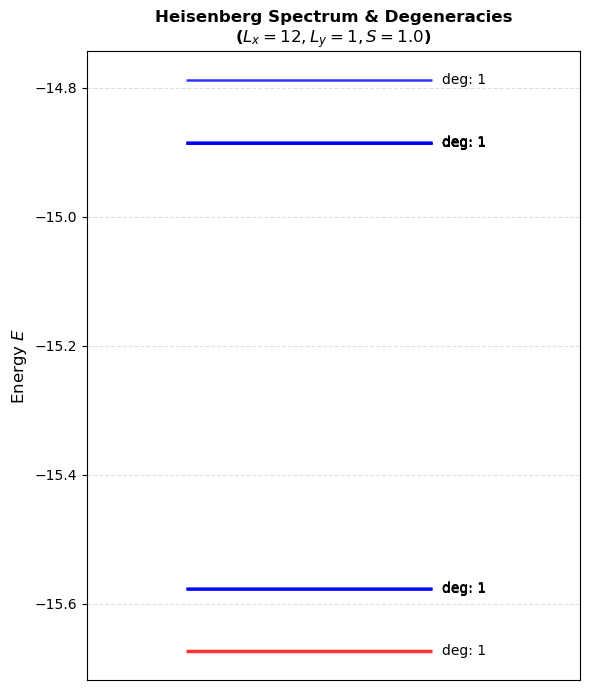

In [4]:
def plot_heisenberg_spectrum(filename, L_x, L_y, S, periodic, h, atol=1e-5):
    """
    Loads eigenvalues from HDF5, calculates the degeneracy of each energy level,
    prints a summary, and plots the spectrum with degeneracy counts.
    """
    group_path = f"L_x_{L_x}/L_y_{L_y}/S_{S}/periodic_{periodic}/h_{h}"
    
    with h5py.File(filename, "r") as f:
        if group_path not in f:
            print(f"Error: Data path '{group_path}' not found in {filename}")
            return
        energies = f[group_path]["energies"][:]
    # --- Calculate Degeneracies ---
    # Group energies that are within 'atol' of each other
    unique_energies = []
    degeneracies = []
    
    for E in energies:
        if not unique_energies:
            unique_energies.append(E)
            degeneracies.append(1)
        else:
            # Check if this energy matches an already identified unique level
            if np.isclose(E, unique_energies[-1], atol=atol):
                degeneracies[-1] += 1
            else:
                unique_energies.append(E)
                degeneracies.append(1)
                
    # --- Print Summary Table ---
    print(f"\n====================================================")
    print(f" SPECTRUM & DEGENERACY: Lx={L_x}, Ly={L_y}, S={S}")
    print(f"====================================================")
    print(f"{'Level Index':<15}{'Energy (E)':<18}{'Degeneracy':<10}")
    print(f"----------------------------------------------------")
    for idx, (E, deg) in enumerate(zip(unique_energies, degeneracies)):
        print(f"{idx:<15}{E:<18.6f}{deg:<10d}")
    print(f"====================================================\n")
    
    print(f"Ground state energy per site: {unique_energies[0]/(L_x*L_y):.6f}")
    if S == 0.5 and L_y == 1:
        print(f"Exact ground state energy per site: {0.25-np.log(2):.6f}")  # For S=1/2 Heisenberg chain, known result
        print(f"Error in ground state energy per site: {abs(unique_energies[0]/(L_x*L_y) - (0.25-np.log(2))):.6e}")
    elif S == 1.0 and L_y == 1:
        # For S=1 Heisenberg chain, the ground state energy per site is known to be approximately -1.401484
        exact_energy_per_site = -1.401484
        print(f"Exact ground state energy per site: {exact_energy_per_site:.6f}")
        print(f"Error in ground state energy per site: {abs(unique_energies[0]/(L_x*L_y) - exact_energy_per_site):.6e}")
        print(f"Exact Haldane gap: {0.4104792485}")  # For S=1 Heisenberg chain, known result
        if periodic == False:
            print(f"Computed Haldane gap (open chain): {abs((unique_energies[2]-unique_energies[0]))}")
            print(f"Quasidegenerate gap (open chain): {abs((unique_energies[1]-unique_energies[0]))}")
        elif periodic == True:
            print(f"Computed Haldane gap (periodic chain): {abs((unique_energies[1]-unique_energies[0]))}")



    # --- Plotting ---
    plt.figure(figsize=(6, 7))
    
    # Plot unique levels and label their degeneracies
    for E, deg in zip(unique_energies, degeneracies):
        # Ground state in red, excited states in blue
        color = 'red' if E == unique_energies[0] else 'blue'
        lw = 2.5 if E == unique_energies[0] else 1.8
        
        plt.hlines(E, xmin=0.2, xmax=0.7, colors=color, linewidth=lw, alpha=0.8)
        
        # Add text label for degeneracy to the right of each line
        plt.text(0.72, E, f"deg: {deg}", verticalalignment='center', fontsize=10, 
                 fontweight='bold' if deg > 1 else 'normal')

    plt.ylabel("Energy $E$", fontsize=12)
    plt.xlim(0, 1.0)
    plt.xticks([])  # Strip X ticks since it's a 1D vertical energy alignment
    plt.title(f"Heisenberg Spectrum & Degeneracies\n($L_x={L_x}, L_y={L_y}, S={S}$)", fontsize=12, fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_heisenberg_spectrum("quantum_heisenberg_data.h5", L_x=12, L_y=1, S=1.0, periodic=False, h=0.001)

### Edge Spin Fractionalization

<font face="serif" color=lightblue> Under open boundary conditions, there is spin-1/2 degree of freedom at the edge of the chain. Since the ground state of finite open chains is a singlet, the edge are coupled antiferromagnetically with each other to form a singlet state. (Can we show through mathematics, or is it just physical intuition?) Therefore, we measure zero magnetization across the chain.

In [154]:
def compute_site_magnetization(filename, L_x, S, periodic=True, h=0.0):
    """
    Loads the ground state wavefunction from the HDF5 file and computes
    the magnetization at each site.
    """
    # 1. Load the ground state wavefunction from your HDF5 archive
    group_path = f"L_x_{L_x}/L_y_1/S_{S}/periodic_{periodic}/h_{h}"
    
    with h5py.File(filename, "r") as f:
        if group_path not in f:
            raise KeyError(f"Data path '{group_path}' not found in {filename}")
        # The ground state is the 0-th column vector
        psi_gs = f[group_path]["states"][:, 0]
    
    hilbert_dim = len(psi_gs)
    d = int(2 * S + 1)  # 2 for S=1/2, 3 for S=1
    
    # 2. Extract Sz configurations for site 0 and site r for all basis states
    # We precompute the local Sz eigenvalues for every state in the Hilbert space
    print(f"Extracting spin configurations for Hilbert space dimension: {hilbert_dim}...")
    
    # sz_table maps a local state index to its physical Sz eigenvalue
    if S == 0.5:
        sz_table = np.array([-0.5, 0.5])
    else:  # S == 1.0
        sz_table = np.array([-1.0, 0.0, 1.0])
    
    distances = np.arange(int(L_x))
    magnetizations = []
    
    print(f"\n--- Site Magnetization ---")
    print(f"{'Distance r':<12}{'<S_r>':<22}")
    print("-" * 22)
    
    # 3. Loop over separation distances
    for r in distances:
        # Extract local state index at site r for every basis state
        # (index // (d**r)) % d yields the state of site r
        szr_values = sz_table[(np.arange(hilbert_dim) // (d**r)) % d]
        
        # Compute <Sz_0 * Sz_r> = \sum_i |psi_i|^2 * Sz_0(i) * Sz_r(i)
        szr_expect = np.sum((psi_gs**2) * szr_values)
            
        magnetizations.append(szr_expect)
        print(f"{r:<12}{szr_expect:<22.6f}")

    print(f"The sum of magnetizations over left half is: {np.sum(magnetizations):.6f}")
        
    return distances, np.array(magnetizations)

# =====================================================================
# Execution Example (run this after your data has been saved)
# =====================================================================
distances, magnetizations = compute_site_magnetization("quantum_heisenberg_data.h5", L_x=14, S=1.0, periodic=False, h=0.0)

Extracting spin configurations for Hilbert space dimension: 4782969...

--- Site Magnetization ---
Distance r  <S_r>                 
----------------------
0           -0.000000             
1           0.000000              
2           -0.000000             
3           0.000000              
4           -0.000000             
5           0.000000              
6           -0.000000             
7           0.000000              
8           -0.000000             
9           0.000000              
10          -0.000000             
11          0.000000              
12          -0.000000             
13          0.000000              
The sum of magnetizations over left half is: -0.000000


<font face="serif" color=lightblue> However, upon perturbing the spin at one edge, we can change the landscape immediately and observe an exponentially decreasing spin-1/2 behaviour.

### Two Spin Correlation

<font face="serif" color=lightblue> For even number of lattice sites, the GS is a singlet, so expectation of spin at site vanishes. The two spin correlation is
$$ |\langle S_0 \cdot S_r \rangle| ~ \begin{cases} \frac{\sqrt{\ln(r)}}{r}, ~~~&\text{if } ~S = 1/2 \\ \frac{e^{-r/\xi}}{\sqrt{r}}, ~~~&\text{if } S=1 \end{cases}$$

In [54]:
def compute_truncated_correlation(filename, L_x, S, periodic=True):
    """
    Loads the ground state wavefunction from the HDF5 file and computes
    the truncated spin-spin correlation function <S_0 . S_r> - <S_0><S_r>.
    """
    # 1. Load the ground state wavefunction from your HDF5 archive
    group_path = f"L_x_{L_x}/L_y_1/S_{S}/periodic_{periodic}"
    
    with h5py.File(filename, "r") as f:
        if group_path not in f:
            raise KeyError(f"Data path '{group_path}' not found in {filename}")
        # The ground state is the 0-th column vector
        psi_gs = f[group_path]["states"][:, 0]
    
    hilbert_dim = len(psi_gs)
    d = int(2 * S + 1)  # 2 for S=1/2, 3 for S=1
    
    # 2. Extract Sz configurations for site 0 and site r for all basis states
    # We precompute the local Sz eigenvalues for every state in the Hilbert space
    print(f"Extracting spin configurations for Hilbert space dimension: {hilbert_dim}...")
    
    # sz_table maps a local state index to its physical Sz eigenvalue
    if S == 0.5:
        sz_table = np.array([-0.5, 0.5])
    else:  # S == 1.0
        sz_table = np.array([-1.0, 0.0, 1.0])
        
    # Extract the local state index at site 0 for every basis state
    # index % d gives the state of site 0
    sz0_values = sz_table[np.arange(hilbert_dim) % d]
    
    # Max distance to compute (r < L_x / 2)
    max_r = int(np.ceil(L_x / 2))
    
    distances = np.arange(max_r)
    correlations = []
    
    print(f"\n--- Truncated Correlation Function C(r) ---")
    print(f"{'Distance r':<12}{'C(r) = <S_0 . S_r>':<22}")
    print("-" * 35)
    
    # 3. Loop over separation distances
    for r in distances:
        if r == 0:
            # Local variance: <S_0 . S_0> = S(S+1)
            c_r = S * (S + 1)
        else:
            # Extract local state index at site r for every basis state
            # (index // (d**r)) % d yields the state of site r
            szr_values = sz_table[(np.arange(hilbert_dim) // (d**r)) % d]
            
            # Compute <Sz_0 * Sz_r> = \sum_i |psi_i|^2 * Sz_0(i) * Sz_r(i)
            sz0_szr_expect = np.sum((psi_gs**2) * sz0_values * szr_values)
            
            # Total correlation due to SU(2) symmetry
            c_r = 3.0 * sz0_szr_expect
            
        correlations.append(c_r)
        print(f"{r:<12}{c_r:<22.6f}")
        
    return distances, np.array(correlations)

# =====================================================================
# Execution Example (run this after your data has been saved)
# =====================================================================
distances, c_r = compute_truncated_correlation("quantum_heisenberg_data.h5", L_x=14, S=1.0, periodic=False)

Extracting spin configurations for Hilbert space dimension: 4782969...

--- Truncated Correlation Function C(r) ---
Distance r  C(r) = <S_0 . S_r>    
-----------------------------------
0           2.000000              
1           -1.629745             
2           0.890999              
3           -0.794251             
4           0.609185              
5           -0.576082             
6           0.491699              



--- Truncated Correlation Function C(r) ---
Distance r  C(r) = <S_0 . S_r>    
-----------------------------------
0           2.000000              
1           -1.629745             
2           0.890999              
3           -0.794251             
4           0.609185              
5           -0.576082             
6           0.491699              

>>> Exponential Fit Results (S=1) <<<
Amplitude (A): 1.3245
Correlation Length (xi): 94.0208 sites (Theoretical Benchmark ~ 6.0)


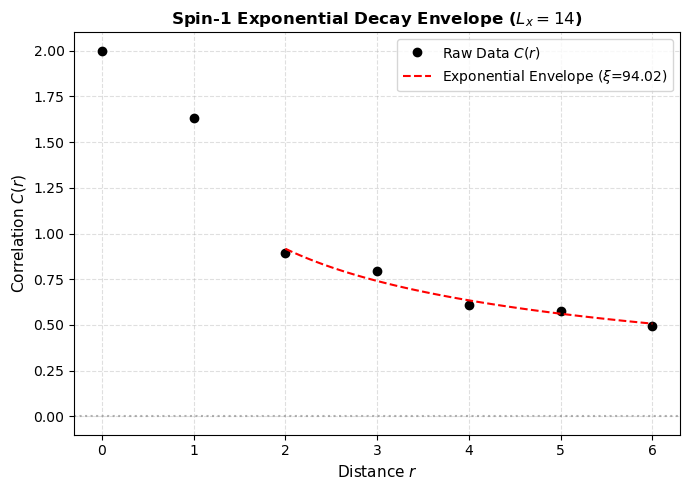

In [55]:
from scipy.optimize import curve_fit

# --- Define the Asymptotic Theoretical Fitting Models ---
def power_law_model(r, A, alpha):
    """Model for S=1/2: C(r) ~ A * sqrt(ln(r)) / r^alpha (Theoretical alpha = 1)"""
    # Guard against ln(r) <= 0 for r=1 by using a small safe epsilon if needed,
    # but since we fit from r >= 2, np.log(r) is always positive.
    return A * np.sqrt(np.log(r)) / (r**alpha)

def exponential_model(r, A, xi):
    """Model for S=1: C(r) ~ A * e^(-r / xi) / sqrt(r)"""
    return A * np.exp(-r / xi) / np.sqrt(r)

def compute_and_fit_correlation(filename, L_x, S, periodic=True):
    """
    Loads ground state wavefunction, computes truncated spin correlation C(r),
    fits the absolute decay envelope to the appropriate theoretical law, and plots.
    """
    # 1. Load the ground state wavefunction from your HDF5 archive
    group_path = f"L_x_{L_x}/L_y_1/S_{S}/periodic_{periodic}"
    
    with h5py.File(filename, "r") as f:
        if group_path not in f:
            raise KeyError(f"Data path '{group_path}' not found in {filename}")
        psi_gs = f[group_path]["states"][:, 0]
    
    hilbert_dim = len(psi_gs)
    d = int(2 * S + 1)
    
    if S == 0.5:
        sz_table = np.array([-0.5, 0.5])
    else:
        sz_table = np.array([-1.0, 0.0, 1.0])
        
    sz0_values = sz_table[np.arange(hilbert_dim) % d]
    max_r = int(np.ceil(L_x / 2))
    
    distances = np.arange(max_r)
    correlations = []
    
    print(f"\n--- Truncated Correlation Function C(r) ---")
    print(f"{'Distance r':<12}{'C(r) = <S_0 . S_r>':<22}")
    print("-" * 35)
    
    for r in distances:
        if r == 0:
            c_r = S * (S + 1)
        else:
            szr_values = sz_table[(np.arange(hilbert_dim) // (d**r)) % d]
            sz0_szr_expect = np.sum((psi_gs**2) * sz0_values * szr_values)
            c_r = 3.0 * sz0_szr_expect
            
        correlations.append(c_r)
        print(f"{r:<12}{c_r:<22.6f}")
        
    correlations = np.array(correlations)
    
    # =====================================================================
    # CURVE FITTING SECTION
    # =====================================================================
    # We fit the absolute value envelope to ignore the staggered sign changes.
    abs_c_r = np.abs(correlations)
    
    # Filter the data: skip r=0 and r=1 to catch true long-range asymptotic behavior
    fit_indices = distances >= 2
    r_fit = distances[fit_indices]
    y_fit = abs_c_r[fit_indices]
    
    plt.figure(figsize=(7, 5))
    # Plot raw data points showing the physical staggered oscillations
    plt.plot(distances, abs_c_r, 'o', label="Raw Data $C(r)$", color='black', markersize=6)
    
    if S == 0.5:
        # Fit Power Law: initial guess A=0.5, alpha=1.0
        popt, pcov = curve_fit(power_law_model, r_fit, y_fit, p0=[0.5, 1.0])
        A_fit, alpha_fit = popt
        
        print(f"\n>>> Power Law Fit Results (S=1/2) <<<")
        print(f"Amplitude (A): {A_fit:.4f}")
        print(f"Decay Exponent (alpha): {alpha_fit:.4f} (Theoretical Target: 1.0)")
        
        # Generate smooth curve for plotting the upper envelope
        r_smooth = np.linspace(2, max_r - 1, 100)
        y_smooth_upper = power_law_model(r_smooth, A_fit, alpha_fit)
        
        plt.plot(r_smooth, y_smooth_upper, '--', color='blue', label=f"Power Law Envelope ($\\alpha$={alpha_fit:.2f})")
        plt.title(f"Spin-1/2 Power Law Decay Envelope ($L_x={L_x}$)", fontsize=12, fontweight='bold')
        
    elif S == 1.0:
        # Fit Exponential: initial guess A=1.0, xi (correlation length)=6.0
        popt, pcov = curve_fit(exponential_model, r_fit, y_fit, p0=[1.0, 6.0])
        A_fit, xi_fit = popt
        
        print(f"\n>>> Exponential Fit Results (S=1) <<<")
        print(f"Amplitude (A): {A_fit:.4f}")
        print(f"Correlation Length (xi): {xi_fit:.4f} sites (Theoretical Benchmark ~ 6.0)")
        
        # Generate smooth curve for plotting the upper envelope
        r_smooth = np.linspace(2, max_r - 1, 100)
        y_smooth_upper = exponential_model(r_smooth, A_fit, xi_fit)
        
        plt.plot(r_smooth, y_smooth_upper, '--', color='red', label=f"Exponential Envelope ($\\xi$={xi_fit:.2f})")
        plt.title(f"Spin-1 Exponential Decay Envelope ($L_x={L_x}$)", fontsize=12, fontweight='bold')

    plt.xlabel("Distance $r$", fontsize=11)
    plt.ylabel("Correlation $C(r)$", fontsize=11)
    plt.axhline(0, color='gray', linestyle=':', alpha=0.6)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return distances, correlations

distances, c_r = compute_and_fit_correlation("quantum_heisenberg_data.h5", L_x=14, S=1.0, periodic=False)